In [1]:
from google.colab import files
uploaded = files.upload()

Saving comb_biov2.zip to comb_biov2.zip


In [2]:
import zipfile
import os

zip_path = "comb_biov2.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped!")

Unzipped!


In [3]:
import os

os.listdir("/content/dataset/comb_biov2")

['labels', 'data.yaml', 'classes.txt', 'images']

In [4]:
data_path = "/content/dataset/comb_biov2/data.yaml"

In [5]:
import yaml

data = {
    "path": "/content/dataset/comb_biov2",
    "train": "images/train",
    "val": "images/val",
    "names": {
        0: "syringes",
        1: "tweezers",
        2: "mask",
        3: "gloves",
        4: "gauze",
        5: "syringe_needles",
        6: "paper_equipment",
        7: "plastic_equipment",
        8: "organic_wastes",
        9: "metal_equipment",
        10: "glass_equipment",
        11: "body_tissue"
    }
}

with open('/content/dataset/comb_biov2/data.yaml', 'w') as f:
    yaml.dump(data, f)

print("DONE ✅")

DONE ✅


In [6]:
with open('/content/dataset/comb_biov2/data.yaml') as f:
    print(f.read())

names:
  0: syringes
  1: tweezers
  2: mask
  3: gloves
  4: gauze
  5: syringe_needles
  6: paper_equipment
  7: plastic_equipment
  8: organic_wastes
  9: metal_equipment
  10: glass_equipment
  11: body_tissue
path: /content/dataset/comb_biov2
train: images/train
val: images/val



In [7]:
!pip uninstall ultralytics -y
!pip install ultralytics --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.4 MB/s eta 0:00:00


In [1]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
model = YOLO("yolov8n.pt")

model.train(
    data="/content/dataset/comb_biov2/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.25 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/comb_biov2/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fb44de722a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

In [3]:
import os

os.listdir("/content/runs/detect")

['train']

In [5]:
os.listdir("/content/runs/detect/train/weights")

['last.pt', 'best.pt']

In [6]:
import os

base = "/content/runs/detect"

for folder in os.listdir(base):
    print("\n📁", folder)
    path = os.path.join(base, folder)
    print(os.listdir(path))


📁 train
['labels.jpg', 'train_batch102.jpg', 'train_batch0.jpg', 'BoxPR_curve.png', 'train_batch2.jpg', 'results.png', 'BoxR_curve.png', 'train_batch100.jpg', 'confusion_matrix_normalized.png', 'args.yaml', 'confusion_matrix.png', 'val_batch0_labels.jpg', 'results.csv', 'BoxP_curve.png', 'train_batch101.jpg', 'BoxF1_curve.png', 'train_batch1.jpg', 'val_batch0_pred.jpg', 'weights']


In [7]:
import os

os.listdir("/content/runs/detect/train/weights")

['last.pt', 'best.pt']

In [8]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

In [9]:
model.predict(
    source="/content/dataset/comb_biov2/images/val",
    save=True,
    conf=0.1   # 👈 VERY IMPORTANT (lower it)
)


image 1/13 /content/dataset/comb_biov2/images/val/18.png: 576x640 1 gloves, 1 plastic_equipment, 495.8ms
image 2/13 /content/dataset/comb_biov2/images/val/21.png: 608x640 1 gloves, 2 plastic_equipments, 496.6ms
image 3/13 /content/dataset/comb_biov2/images/val/27.png: 608x640 1 gauze, 2 plastic_equipments, 390.7ms
image 4/13 /content/dataset/comb_biov2/images/val/33.png: 576x640 1 gloves, 193.4ms
image 5/13 /content/dataset/comb_biov2/images/val/46.jpeg: 608x640 1 gauze, 215.4ms
image 6/13 /content/dataset/comb_biov2/images/val/51.jpeg: 640x544 1 gauze, 215.0ms
image 7/13 /content/dataset/comb_biov2/images/val/52.jpeg: 480x640 1 gloves, 169.4ms
image 8/13 /content/dataset/comb_biov2/images/val/IMG_6288_JPG.rf.0f969d888de625b70b8482013ee16ac6.jpg: 640x640 2 syringe_needless, 243.1ms
image 9/13 /content/dataset/comb_biov2/images/val/IMG_6298_JPG.rf.c1a2fecfa2219c2d27dd774d2852e11d.jpg: 640x640 1 gloves, 215.9ms
image 10/13 /content/dataset/comb_biov2/images/val/IMG_6322_JPG.rf.1d51617be

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'syringes', 1: 'tweezers', 2: 'mask', 3: 'gloves', 4: 'gauze', 5: 'syringe_needles', 6: 'paper_equipment', 7: 'plastic_equipment', 8: 'organic_wastes', 9: 'metal_equipment', 10: 'glass_equipment', 11: 'body_tissue'}
 obb: None
 orig_img: array([[[  6, 142, 195],
         [  4, 142, 194],
         [  3, 143, 194],
         ...,
         [ 45, 177, 221],
         [ 53, 179, 223],
         [ 60, 181, 224]],
 
        [[  6, 142, 195],
         [  4, 143, 195],
         [  3, 142, 193],
         ...,
         [ 25, 167, 215],
         [ 32, 168, 215],
         [ 38, 168, 216]],
 
        [[  7, 142, 195],
         [  5, 143, 194],
         [  3, 142, 193],
         ...,
         [ 13, 163, 215],
         [ 18, 162, 214],
         [ 22, 161, 213]],
 
        ...,
 
        [[ 60, 168, 208],
         [ 59, 168, 207],
         [ 57, 168, 207],

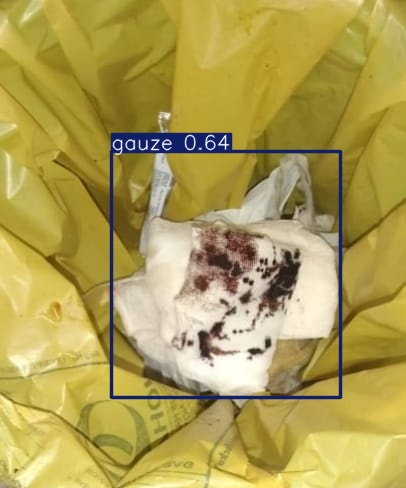

In [10]:
from IPython.display import Image, display

files = os.listdir("/content/runs/detect/predict")
display(Image(filename="/content/runs/detect/predict/" + files[0]))

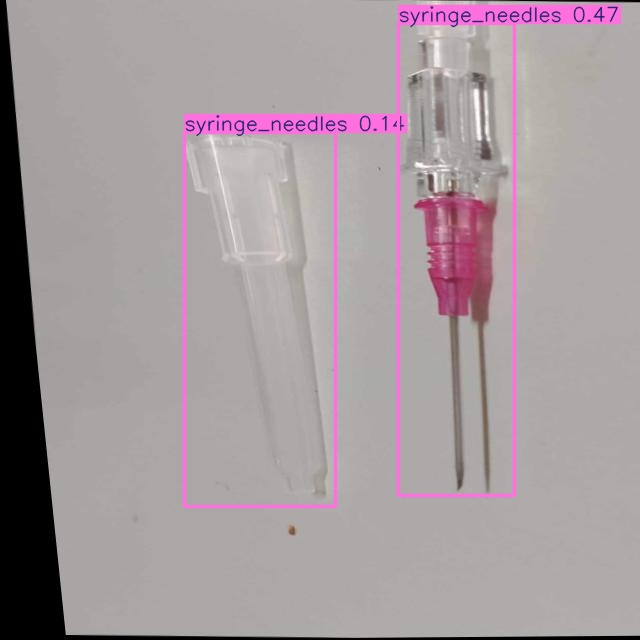

In [11]:
from IPython.display import Image, display

files = os.listdir("/content/runs/detect/predict")
display(Image(filename="/content/runs/detect/predict/" + files[1]))

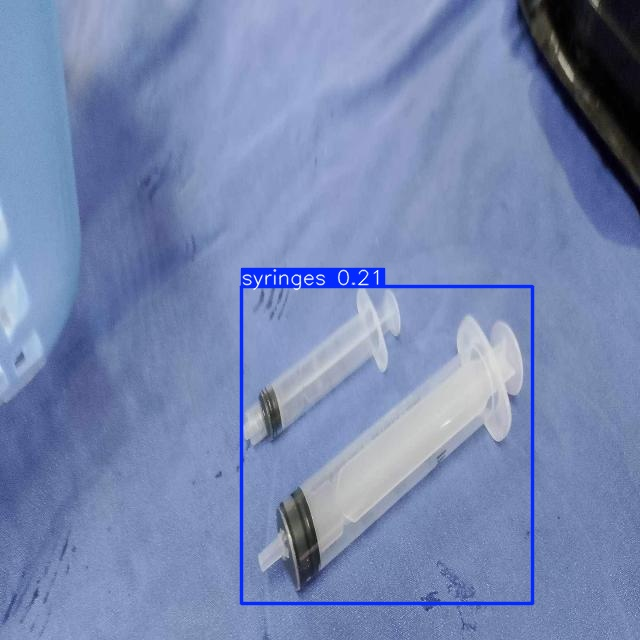

In [12]:
from IPython.display import Image, display

files = os.listdir("/content/runs/detect/predict")
display(Image(filename="/content/runs/detect/predict/" + files[4]))

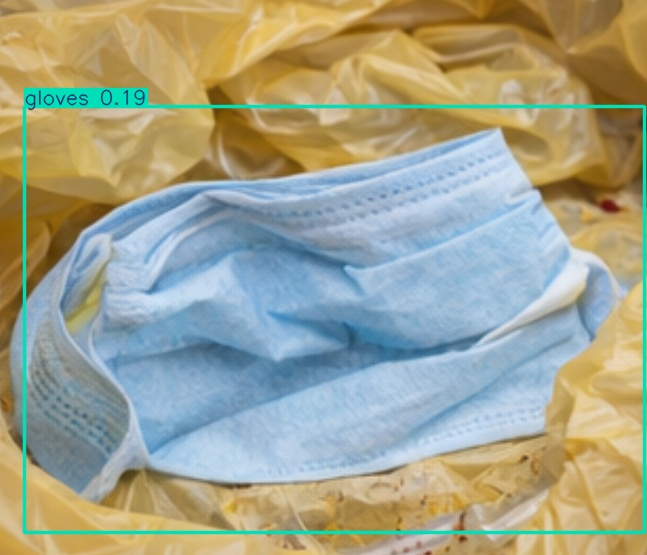

In [13]:
from IPython.display import Image, display

files = os.listdir("/content/runs/detect/predict")
display(Image(filename="/content/runs/detect/predict/" + files[3]))

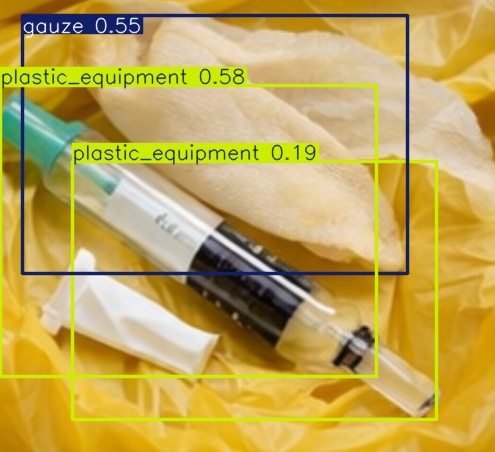

In [14]:
from IPython.display import Image, display

files = os.listdir("/content/runs/detect/predict")
display(Image(filename="/content/runs/detect/predict/" + files[8]))